# Pandas

[*pandas*](http://pandas.pydata.org/) is a column-oriented data analysis API. It's a great tool for handling and analyzing input data, and many ML frameworks support *pandas* data structures as inputs.
Although a comprehensive introduction to the *pandas* API would span multiple lectures, the core concepts are fairly straightforward, and we'll present them below.

### At the end of this notebook, you'll be able to:
* Gain an introduction to the `DataFrame` data structure of the *pandas* library
* Access and manipulate data within a `DataFrame`
* Import CSV data into a *pandas* `DataFrame`

### Table of Contents
1. [Part I. Series and Dataframes](#one)
2. [Part II. Manipulating Data](#two)
3. [Part III. Plotting Data](#three)

<hr>

In [ ]:
!pip3 install pandas #if you don't have pandas already installed

In [2]:
import pandas as pd

<a id="one"></a>
## Part I. Series and Dataframes

The primary data structures in *pandas* are implemented as two classes:

  * **`DataFrame`**, which you can imagine as a relational data table, with rows and named columns.
  * **`Series`**, which is a single column. A `DataFrame` contains one or more `Series` and a name for each `Series`.

The data frame is a commonly used abstraction for data manipulation. Similar implementations exist in [Spark](https://spark.apache.org/) and [R](https://www.r-project.org/about.html).

One way to create a `Series` is to construct a `Series` object. For example:

In [4]:
my_series = pd.Series(['Manhattan', 'Brooklyn', 'Queens'])

my_series

0    Manhattan
1     Brooklyn
2       Queens
dtype: object

`DataFrame` objects can be created by passing a `dict` mapping `string` column names to their respective `Series`. If the `Series` don't match in length, missing values are filled with special empty values. Example:

In [3]:
borough_names = pd.Series(['Manhattan', 'Brooklyn', 'Queens'])
population = pd.Series([1627788, 2736074, 2330124])
live_here = pd.Series([False, True, False])

my_dataframe = pd.DataFrame({ 'Borough name': borough_names, 
                              'Population': population,
                              'Live here': live_here})
my_dataframe

,Borough name,Population,Live here
0,Manhattan,1627788,False
1,Brooklyn,2736074,True
2,Queens,2330124,False


><b>Task:</b>
> Make a data frame with the following details:
>
> Column names: Major, Major Code
>
> Column1 - Major - [Mathematics, Computer Science, Psychology, Political Science, English]
>
> Column2 - Major Code - [MATH, CSCI, PSYCH, POLSCI, ENGL]

In [15]:
major = pd.Series(['Mathematics', 'Computer Science', 'Psychology', 'Political Science', 'English'])
major_codes = pd.Series(['MATH', 'CSCI', 'PSYCH', 'POLSCI', 'ENGL'])

my_dataframe = pd.DataFrame({ 'Major': major, 
                              'Major Codes': major_codes})
my_dataframe

,Major,Major Codes
0,Mathematics,MATH
1,Computer Science,CSCI
2,Psychology,PSYCH
3,Political Science,POLSCI
4,English,ENGL


But most of the time, you load an entire file into a `DataFrame`. The following example loads a file with California housing data. Run the following cell to load the data and create feature definitions:

In [30]:
california_housing_dataframe = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/california_housing_train.csv", sep=",")

In [31]:
california_housing_dataframe

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0
...,...,...,...,...,...,...,...,...,...
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0


The example above used `DataFrame.describe` to show interesting statistics about a `DataFrame`. Another useful function is `DataFrame.head`, which displays the first few records of a `DataFrame`:

In [18]:
california_housing_dataframe.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [20]:
california_housing_dataframe.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Another powerful feature of *pandas* is graphing. For example, `DataFrame.hist` lets you quickly study the distribution of values in a column:

array([[<Axes: title={'center': 'housing_median_age'}>]], dtype=object)

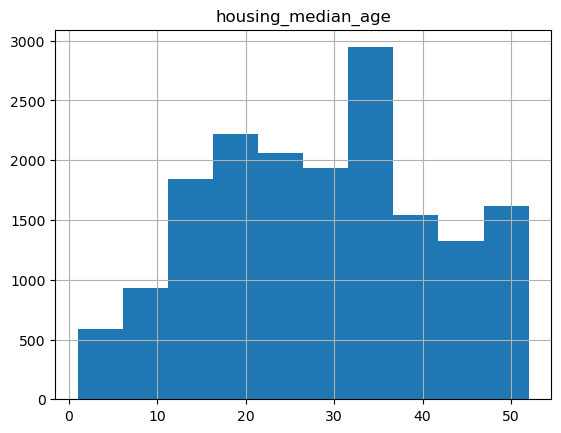

In [22]:
california_housing_dataframe.hist('housing_median_age')

### Accessing Data

You can access `DataFrame` data using familiar Python list operations:

In [25]:
my_dataframe = pd.DataFrame({ 'Borough name': borough_names, 'Population': population })

0    Manhattan
1     Brooklyn
2       Queens
Name: Borough name, dtype: object

In [26]:
print(type(my_dataframe['Borough name']))

<class 'pandas.core.series.Series'>


In [27]:
my_dataframe['Borough name']

0    Manhattan
1     Brooklyn
2       Queens
Name: Borough name, dtype: object

In [28]:
my_dataframe['Borough name'][1]

'Brooklyn'

In [29]:
my_dataframe[0:2]

,Borough name,Population
0,Manhattan,1627788
1,Brooklyn,2736074


><b>Task:</b>
> Pick your own dataset from [here](https://www.kaggle.com/)
>
> Make sure the dataset is in the same directory as this notebook
>
> Generate some summary statistics (`.describe()`)
>
> Preview the first couple entries (`.head()`)
>
> Plot a histogram for a relevant column

In [4]:
my_df = pd.read_csv("air_quality_health_dataset.csv")

In [5]:
my_df

,city,date,aqi,pm2_5,pm10,no2,o3,temperature,humidity,hospital_admissions,population_density,hospital_capacity
0,Los Angeles,2020-01-01,65,34.0,52.7,2.2,38.5,33.5,33,5,Rural,1337
1,Beijing,2020-01-02,137,33.7,31.5,36.7,27.5,-1.6,32,4,Urban,1545
2,London,2020-01-03,266,43.0,59.6,30.4,57.3,36.4,25,10,Suburban,1539
3,Mexico City,2020-01-04,293,33.7,37.9,12.3,42.7,-1.0,67,10,Urban,552
4,Delhi,2020-01-05,493,50.3,34.8,31.2,35.6,33.5,72,9,Suburban,1631
...,...,...,...,...,...,...,...,...,...,...,...,...
88484,Tokyo,2262-04-06,22,23.4,53.4,24.3,58.9,9.1,55,5,Suburban,419
88485,Delhi,2262-04-07,170,48.0,32.4,25.0,15.7,5.6,40,10,Urban,695
88486,Delhi,2262-04-08,307,46.7,21.8,31.9,45.1,9.5,44,12,Urban,245
88487,Beijing,2262-04-09,65,31.9,26.0,38.1,53.0,17.8,46,11,Suburban,1291


In [18]:
my_df.describe()

,aqi,pm2_5,pm10,no2,o3,temperature,humidity,hospital_admissions,hospital_capacity
count,88489.000000,88489.000000,88489.000000,88489.000000,88489.000000,88489.000000,88489.000000,88489.000000,88489.000000
mean,249.370182,35.144951,50.118654,30.006211,39.978895,17.522962,56.950966,8.049385,1024.463165
std,144.479132,14.767994,19.796392,9.963139,12.007258,12.961024,21.629675,3.715458,561.978071
min,0.000000,0.000000,0.000000,0.000000,0.000000,-5.000000,20.000000,0.000000,50.000000
25%,124.000000,24.900000,36.600000,23.300000,31.900000,6.400000,38.000000,6.000000,539.000000
50%,249.000000,35.100000,50.000000,30.000000,40.000000,17.500000,57.000000,8.000000,1026.000000
75%,374.000000,45.200000,63.500000,36.700000,48.100000,28.700000,76.000000,10.000000,1511.000000
max,499.000000,109.900000,143.500000,71.400000,93.500000,40.000000,94.000000,25.000000,1999.000000


In [7]:
my_df.head()

,city,date,aqi,pm2_5,pm10,no2,o3,temperature,humidity,hospital_admissions,population_density,hospital_capacity
0,Los Angeles,2020-01-01,65,34.0,52.7,2.2,38.5,33.5,33,5,Rural,1337
1,Beijing,2020-01-02,137,33.7,31.5,36.7,27.5,-1.6,32,4,Urban,1545
2,London,2020-01-03,266,43.0,59.6,30.4,57.3,36.4,25,10,Suburban,1539
3,Mexico City,2020-01-04,293,33.7,37.9,12.3,42.7,-1.0,67,10,Urban,552
4,Delhi,2020-01-05,493,50.3,34.8,31.2,35.6,33.5,72,9,Suburban,1631


array([[<Axes: title={'center': 'hospital_capacity'}>]], dtype=object)

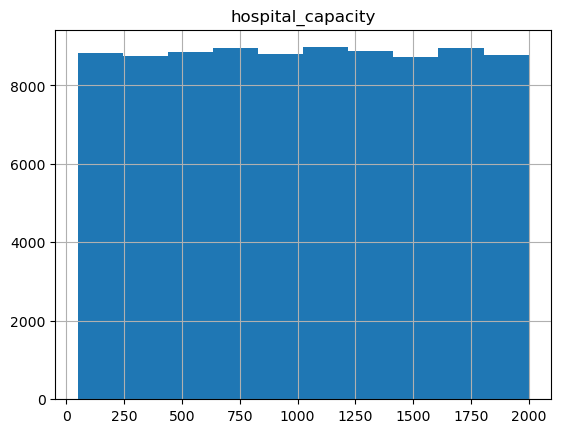

In [8]:
my_df.hist('hospital_capacity')

<a id="one"></a>
## Part II. Manipulating Data

You may apply Python's basic arithmetic operations to `Series`. For example:

In [14]:
population * 1000

0    1627788000
1    2736074000
2    2330124000
dtype: int64

In [15]:
my_dataframe

,Borough name,Population,Live here
0,Manhattan,1627788,False
1,Brooklyn,2736074,True
2,Queens,2330124,False


Modifying `DataFrames` is also straightforward. For example, the following code adds two `Series` to an existing `DataFrame`:

In [16]:
my_dataframe['Area (mi^2)'] = pd.Series([22.82, 69.4, 108.7])
my_dataframe['Population Density (ppl/mi^2)'] = my_dataframe['Population'] / my_dataframe['Area (mi^2)']

my_dataframe

,Borough name,Population,Live here,Area (mi^2),Population Density (ppl/mi^2)
0,Manhattan,1627788,False,22.82,71331.638913
1,Brooklyn,2736074,True,69.40,39424.697406
2,Queens,2330124,False,108.70,21436.283349


Earlier on we used the `.describe()` function to generate summary statistics, however we can ask for statistics on a specific `Series`

In [19]:
my_dataframe['Area (mi^2)'].median()

np.float64(69.4)

In [20]:
my_dataframe['Population Density (ppl/mi^2)'].mean()

np.float64(44064.20655608003)

In [21]:
my_dataframe['Population'].std()

np.float64(560709.2409309243)

In [22]:
my_dataframe.corr(numeric_only = True) # corr = correlation coefficient

,Population,Live here,Area (mi^2),Population Density (ppl/mi^2)
Population,1.000000,0.779588,0.663653,-0.742283
Live here,0.779588,1.000000,0.048883,-0.159005
Area (mi^2),0.663653,0.048883,1.000000,-0.993870
Population Density (ppl/mi^2),-0.742283,-0.159005,-0.993870,1.000000


><b>Task:</b>
> Fill in the table

| Function | What it is                                 | 
|----------|---------------------------------------------
| mean      |              The average value of your data            |                
| median    |               The middlemost value in your data                  |                 
| std       |               How spread out your data is                              |                 
| min       |         minimum          |                 
| max       |         maximum                           |                 
| corr      | how correlated (strongly related) two columns are          |              

><b>Task:</b>
> In your personal dataset:
>
> Pick a column and find the standard deviation and mean.
>
> Comment on the center of your data, and the spread of your data
>
> Generate the correlation matrix for your data, comment on a intresting correlation in your dataset

In [23]:
my_df.head()

,city,date,aqi,pm2_5,pm10,no2,o3,temperature,humidity,hospital_admissions,population_density,hospital_capacity
0,Los Angeles,2020-01-01,65,34.0,52.7,2.2,38.5,33.5,33,5,Rural,1337
1,Beijing,2020-01-02,137,33.7,31.5,36.7,27.5,-1.6,32,4,Urban,1545
2,London,2020-01-03,266,43.0,59.6,30.4,57.3,36.4,25,10,Suburban,1539
3,Mexico City,2020-01-04,293,33.7,37.9,12.3,42.7,-1.0,67,10,Urban,552
4,Delhi,2020-01-05,493,50.3,34.8,31.2,35.6,33.5,72,9,Suburban,1631


In [25]:
my_df['temperature'].median()

np.float64(17.5)

In [26]:
my_df['temperature'].std()

np.float64(12.96102407149432)

In [27]:
my_df.corr(numeric_only = True)

,aqi,pm2_5,pm10,no2,o3,temperature,humidity,hospital_admissions,hospital_capacity
aqi,1.000000,0.002894,0.001948,0.002683,-0.001849,-0.004377,-0.003098,-0.000393,0.004591
pm2_5,0.002894,1.000000,-0.000083,0.004913,-0.000791,-0.006202,0.002752,0.392309,0.002705
pm10,0.001948,-0.000083,1.000000,0.003693,0.001197,-0.001465,0.006189,0.000537,0.000830
no2,0.002683,0.004913,0.003693,1.000000,-0.000741,0.002951,0.005071,0.001279,0.005961
o3,-0.001849,-0.000791,0.001197,-0.000741,1.000000,-0.000031,-0.004403,-0.003032,-0.004052
temperature,-0.004377,-0.006202,-0.001465,0.002951,-0.000031,1.000000,-0.004595,-0.003783,0.006699
humidity,-0.003098,0.002752,0.006189,0.005071,-0.004403,-0.004595,1.000000,0.000010,0.006118
hospital_admissions,-0.000393,0.392309,0.000537,0.001279,-0.003032,-0.003783,0.000010,1.000000,0.001533
hospital_capacity,0.004591,0.002705,0.000830,0.005961,-0.004052,0.006699,0.006118,0.001533,1.000000


<a id="Three"></a>
## Part III. Plotting Data

Plotting is largely done through a package called `matplotlib`. `matplotlib` is the package, but really what we want is one particular part from it called `pyplot`. So we'll just import that part. To do that, we type `from matplotlib import pyplot`. Again, it's a hassle to type `pyplot` over and over, so we'll alias it as `plt`.

In [28]:
import matplotlib.pyplot as plt

`pyplot` supports several ways to plot data. If you have your data in a Pandas DataFrame (as we do), one thing you can do is to directly plot the DataFrame. This is as simple as adding `.plot()` to the end of your DataFrame. Let's try it below.

<Axes: >

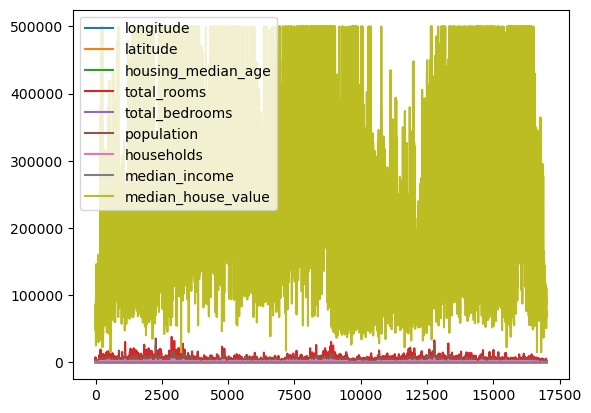

In [32]:
california_housing_dataframe.plot()

That *works*, but it plots *all* of the columns at once. That's probably not what we really want. Instead, let's just plot the "total_rooms" variable.

<Axes: >

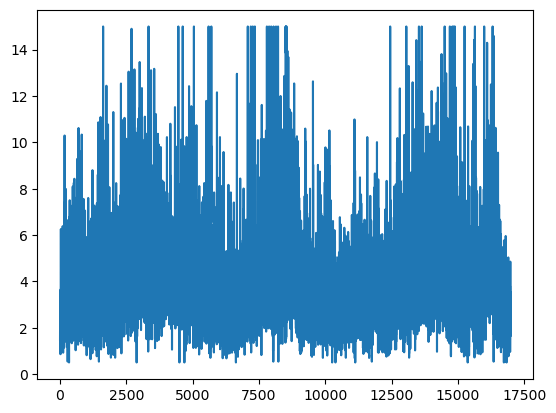

In [35]:
california_housing_dataframe['median_income'].plot()

That's an improvement, but it's plotting "total_rooms" as a line plot. Probably what we really want is a histogram. To tell `matplotlib` we want a histogram, just add `kind="hist"` to the `plot` command.

<Axes: >

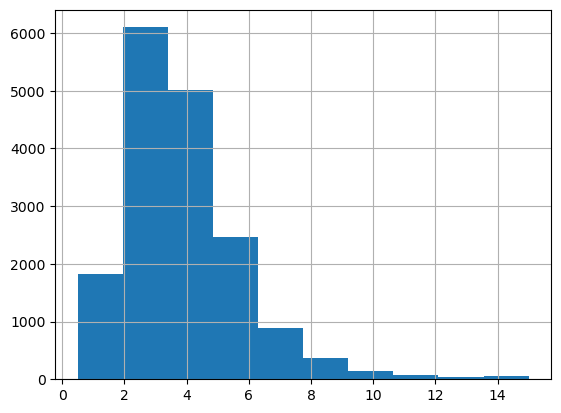

In [36]:
california_housing_dataframe['median_income'].hist()

Let's try to find two columns that are highly correlated (or uncorrelated) to plot

In [37]:
california_housing_dataframe.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.925208,-0.114250,0.047010,0.071802,0.101674,0.059628,-0.015485,-0.044982
latitude,-0.925208,1.000000,0.016454,-0.038773,-0.069373,-0.111261,-0.074902,-0.080303,-0.144917
housing_median_age,-0.114250,0.016454,1.000000,-0.360984,-0.320434,-0.295890,-0.302754,-0.115932,0.106758
total_rooms,0.047010,-0.038773,-0.360984,1.000000,0.928403,0.860170,0.919018,0.195383,0.130991
total_bedrooms,0.071802,-0.069373,-0.320434,0.928403,1.000000,0.881169,0.980920,-0.013495,0.045783
population,0.101674,-0.111261,-0.295890,0.860170,0.881169,1.000000,0.909247,-0.000638,-0.027850
households,0.059628,-0.074902,-0.302754,0.919018,0.980920,0.909247,1.000000,0.007644,0.061031
median_income,-0.015485,-0.080303,-0.115932,0.195383,-0.013495,-0.000638,0.007644,1.000000,0.691871
median_house_value,-0.044982,-0.144917,0.106758,0.130991,0.045783,-0.027850,0.061031,0.691871,1.000000


Looks like there is a strong relationship between the # of total bedrooms and population (0.881169), let's visualize it by plotting the # of total bedrooms on the x axis and the population on the y axis on a scatter plot

<Axes: xlabel='total_rooms', ylabel='housing_median_age'>

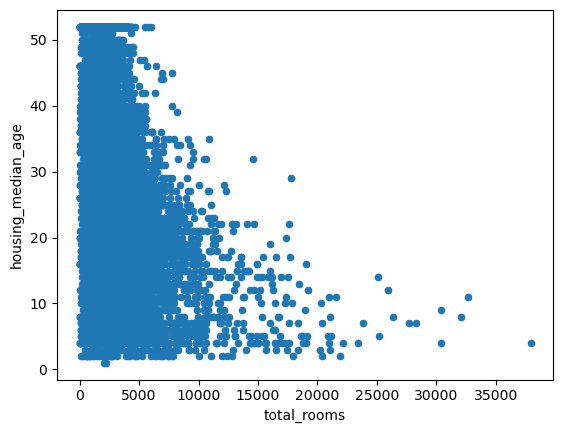

In [39]:
california_housing_dataframe.plot.scatter(x='total_rooms', y='')

Looks to be strongly correlated! As the number of total bedrooms goes up, so does the population!

><b>Task:</b>
> In your personal dataset:
>
> a) Plot 3 graphs, one scatter, one histogram, and one line plot.
>
> b) Find two series that are strongly correlated (positive/negative), plot rationally, and comment on why this correlation exists
>
> c) After working with your dataset, comment on some intresting findings/correlations/features of your dataset that you observed.

In [ ]:
# "https://download.mlcc.google.com/mledu-datasets/california_housing_train.csv"
# air_quality_health_dataset.csv

In [43]:
my_file = input("Enter a file to check: ")
my_dataframe2 = pd.read_csv(my_file)
my_dataframe2.head()

 https://download.mlcc.google.com/mledu-datasets/california_housing_train.csv


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0
